# Prolog

In [1]:
import pandas as pd
import seaborn as sb
import os
import OHCParser as op
import datetime
import traceback
from scipy.optimize import curve_fit
import pathlib
from matplotlib import pyplot as plt

In [2]:
dfs = op.read_submissions()
dfs = op.derive_metrics(dfs)

last time the data was updated 2026-03-27 08:31:56.368997  by  go
03_OHC1_DrivAer_Result_Template_v3 Ruggero Poletto.xlsm: No energy data found
05_Huawei_OHC1_DrivAer_Result_Software_MxP_Fine.xlsm: number of timestep != number of wall clock time, assuming partial run
05_Huawei_OHC1_DrivAer_Result_Software_MxP_Fine.xlsm: trying to fill wct, this makes only sense if N/A cases are contiguously to the right at the moment
05_Huawei_OHC1_DrivAer_Result_Software_MxP_Fine.xlsm: No energy data found
08_OHC1_DrivAer_Result_inductiva_65M Gabriel Marcos Magalhães.xlsm: No energy data found
10_Olenik_OHC1_FTP_S_MILAN250_CPU.xlsm: No energy data found


/Users/go/venvs/neofoam/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
/Users/go/venvs/neofoam/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [3]:
# Serialize forces we try to read in all even if most of them fail
_,_,fs = next(os.walk("submissions"))

dfsf = pd.DataFrame()
for fn in fs:
    if not fn.endswith("xlsm"):
        continue
    try:
        df_meta = pd.read_excel("submissions/" + fn, sheet_name="META Data")
        df_forces = pd.read_excel("submissions/" + fn, sheet_name="Aero Forces")
        dft=op.serialize_forces(df_forces, df_meta, fn)
    except Exception as e:
        print(f"failed force serialization {fn}")
        print(traceback.format_exc())
    dfsf = pd.concat([dfsf,dft])

/Users/go/venvs/neofoam/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
/Users/go/venvs/neofoam/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [4]:
df_hardware = dfs[dfs["Track"] == "Hardware Track"]
df_software = dfs[dfs["Track"] == "Software Track"]

fig_folder = "figures_swtrack"
doSaveFig = True  # Set to True to save figures

saving figure to figures_swtrack/Count_Mesh_Track.png


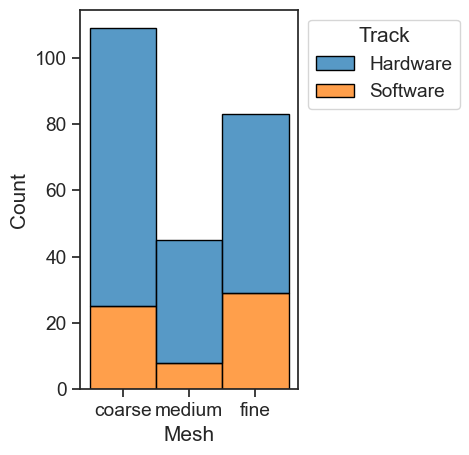

In [9]:
sb.set(style="ticks", font_scale=1.25, palette=sb.color_palette())  # crazy big
dfs['Track'] = dfs['Track'].apply(lambda x: x.split()[0])
dfs['Mesh'] = pd.Categorical(dfs['Mesh'], ['coarse','medium','fine'])
ax = sb.histplot(dfs, x="Mesh",
            hue="Track",
            #hue="Contributor ID", 
            multiple="stack",
            stat="count",
            ec="k"
            )
ax.set_aspect(0.05)

sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
op.save_fig(ax.get_figure(), fig_folder, "Count_Mesh_Track", doSaveFig)

/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_79372/4246307649.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_79372/4246307649.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


saving figure to figures_swtrack/Count_Nodes_Category.png


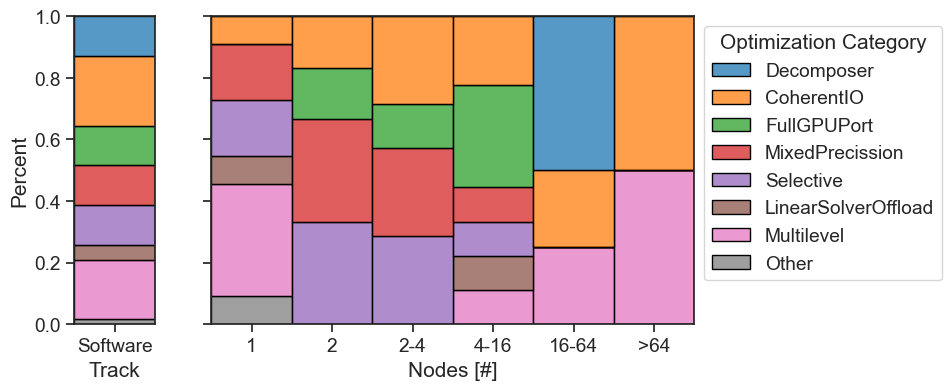

In [14]:
df_software["Nodes [#]"] = pd.cut(
    df_software["Number of Nodes"], 
    bins=[0.01,1,2,4,16, 64,64000], 
    labels=["1","2","2-4","4-16", "16-64", ">64"])

fig, axs = plt.subplots(1, 2, figsize=(8, 4), layout="constrained", gridspec_kw={"hspace": 0.5, 'width_ratios': [1, 6]}, sharey=True)
df_software["Optimization Category"] = df_software["Software Optimization Category"]
df_software['Track'] = df_software['Track'].apply(lambda x: x.split()[0])

ax = sb.histplot(df_software, x="Track",
            hue="Optimization Category",
            #hue="Contributor ID", 
            multiple="fill",
            stat="percent",
            ax=axs[0],
            ec="k"
           )
axs[0].get_legend().set_visible(False)

ax = sb.histplot(df_software, x="Nodes [#]",
            hue="Optimization Category",
            #hue="Contributor ID", 
            multiple="fill",
            stat="percent",
            ax=axs[1],
            ec="k"
           )

sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
op.save_fig(ax.get_figure(), fig_folder, "Count_Nodes_Category", doSaveFig)

saving figure to figures_swtrack/Count_Nodes_Category.png


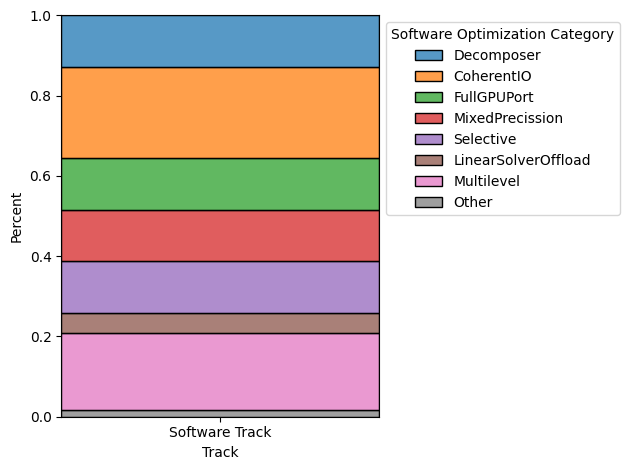

In [37]:
ax = sb.histplot(df_software, x="Track",
            hue="Software Optimization Category",
            #hue="Contributor ID", 
            multiple="fill",
            stat="percent"
           )
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
op.save_fig(ax.get_figure(), fig_folder, "Count_Nodes_Category", doSaveFig)

In [83]:
# olympic swimming pool 50m*25m*2m 2.5e6 l water
V = 2.5e6 #l water
cp = 4.184  # kJ / kg⋅K
dT = 80 #K,
rho = 1 #kg/l
# 1kJ = 0.0002778 kWh
e = V * rho * dT * cp * 0.0002778

In [84]:
set(dfs['Software Optimization Category'])

{'CoherentIO',
 'Decomposer',
 'FullGPUPort',
 'LinearSolverOffload',
 'MixedPrecission',
 'Multilevel',
 'Other',
 'Selective'}

In [85]:
df_software["Type"] = "Other"
df_software.loc[df_software["Contributor Affiliation"] == "Cineca", "Type"] = "Full GPU port"
df_software.loc[df_software["Contributor Affiliation"] == "Engys", "Type"] = "Full GPU port"
df_software.loc[df_software["Contributor Affiliation"] == "KIT/TUM", "Type"] = "GPU Plugin"
df_software_fine = df_software[df_software["Mesh"]=="fine"]
df_hardware_fine = df_hardware[df_hardware["Mesh"]=="fine"]
df_software_coarse = df_software[df_software["Mesh"]=="coarse"]
df_hardware_coarse = df_hardware[df_hardware["Mesh"]=="coarse"]
df_software_medium = df_software[df_software["Mesh"]=="medium"]
df_hardware_medium = df_hardware[df_hardware["Mesh"]=="medium"]
df_software_wo_GPU = df_software[df_software["Type"] != "Full GPU port"]

df_software.columns

Index(['Contributor Affiliation', 'File Name', 'Run Wall-Clock Time [s]',
       'Pre-Processing Wall-Clock Time [s]', 'Storage File-System',
       'Number of CPU Cores', 'Number of GPU Devices', 'Number of Nodes',
       'CPU Family', 'CPU Model', 'CPU Submodel', 'CPU Generation',
       'GPU Model', 'Mesh', 'System TDP [W]', 'Number of Cells',
       'Time per Iteration [s]', 'Track', 'OpenFOAM Flavor',
       'Run Consumed Energy [kWh]', 'Decomposition Method', 'Last-Level Cache',
       'Network Interconnect', 'Renumbering Method', 'Contributor ID',
       'Is Partial', 'Is Energy Reported', 'Software Optimization Category',
       'Total Core Time [s]', 'Total Node Time [s]',
       'Energy per Iteration [J]', 'Energy per Iteration [kJ]',
       'Energy-To-Solution [kWh]', 'Time-To-Solution [h]',
       'Core-Time-To-Solution [h]', 'Node-Time-To-Solution [h]', 'FVOPS',
       'FVOPS per Energy', 'FVOPS per Energy per Iteration', 'FVOPS per Node',
       'Nodes [#]', 'Optimization

# General

In [86]:
# some statistics
print(f"""
total number of valid entries: {len(df_software)} / {len(dfs)},
Contributor ID: {set(df_software["Contributor ID"])}  ,
software track entries {len(df_software)} ,
processesed {len(set(dfs['CPU Model']))} different CPU vendors {set(dfs['CPU Model'])},
processesed {len(set(dfs['GPU Model']))} different GPUmodels {set(dfs['GPU Model'])},
-------------------
break-down by CPU model: {dfs["CPU Model"].value_counts()}
-------------------
-------------------
break-down by GPUmodel: {dfs["GPU Model"].value_counts()}
-------------------
max nodes {max(dfs['Number of Nodes'])},
max cores {max(dfs['Number of CPU Cores'])},
min wall clc {min(dfs['Run Wall-Clock Time [s]'])},
min time step software fine {min(df_software_fine['Time per Iteration [s]'])},
min time step hardware fine {min(df_hardware_fine['Time per Iteration [s]'])},
min time step hardware factor  {1-min(df_software_fine['Time per Iteration [s]'])/min(df_hardware_fine['Time per Iteration [s]'])},
min time step software medium {min(df_software_medium['Time per Iteration [s]'])},
min time step hardware medium {min(df_hardware_medium['Time per Iteration [s]'])},
min time step hardware factor  {1-min(df_software_medium['Time per Iteration [s]'])/min(df_hardware_medium['Time per Iteration [s]'])},
min time step software coarse {min(df_software_coarse['Time per Iteration [s]'])},
min time step hardware coarse {min(df_hardware_coarse['Time per Iteration [s]'])},
min time step hardware factor  {1-min(df_software_coarse['Time per Iteration [s]'])/min(df_hardware_coarse['Time per Iteration [s]'])},

min energy software {min(df_software['Energy per Iteration [J]'])} [J],
min energy hardware {min(df_hardware['Energy per Iteration [J]'])} [J],
max FVOPS {max(df_software['FVOPS'])/1e6} [MFVOPS],
max FVOPS {max(df_hardware['FVOPS'])/1e6} [MFVOPS],
max FVOPS/node {max(df_software['FVOPS per Node'])/1e6} [MFVOPS],
max FVOPS/node {max(df_software_wo_GPU['FVOPS per Node'])/1e6} [MFVOPS],
max FVOPS/node {max(df_hardware['FVOPS per Node'])/1e6} [MFVOPS],
max energy {max(dfs['Energy-To-Solution [kWh]'])} [kWh],
total reported energy consumption {sum(dfs['Energy-To-Solution [kWh]'])} kWh, bringing {sum(dfs['Energy-To-Solution [kWh]'])/e} olympic swimming pools worth of water to a boil
decomposition methods {set(dfs["Decomposition Method"])},
renumbering methods {set(dfs["Renumbering Method"])}
network {set(dfs["Network Interconnect"])},
""")


total number of valid entries: 62 / 237,
Contributor ID: {'10', '15', '01', '04', '05'}  ,
software track entries 62 ,
processesed 7 different CPU vendors {'Instinct', 'EPYC', 'LX2', 'Core', 'Neoverse', 'Xeon', 'Fujitsu'},
processesed 4 different GPUmodels {'NVIDIA A100-40', 'NVIDIA A100-64', 'AMD MI100', 'N/A'},
-------------------
break-down by CPU model: CPU Model
EPYC        106
Xeon         79
LX2          25
Fujitsu      18
Neoverse      7
Core          1
Instinct      1
Name: count, dtype: int64
-------------------
-------------------
break-down by GPUmodel: GPU Model
N/A               227
NVIDIA A100-64      6
NVIDIA A100-40      3
AMD MI100           1
Name: count, dtype: int64
-------------------
max nodes 256,
max cores 32768,
min wall clc 0.0,
min time step software fine 0.319962533001001,
min time step hardware fine 0.3748,
min time step hardware factor  0.1463112780122705,
min time step software medium 0.3618,
min time step hardware medium 0.651198350911726,
min time ste

saving figure to figures_swtrack/wct_cores_mesh.png


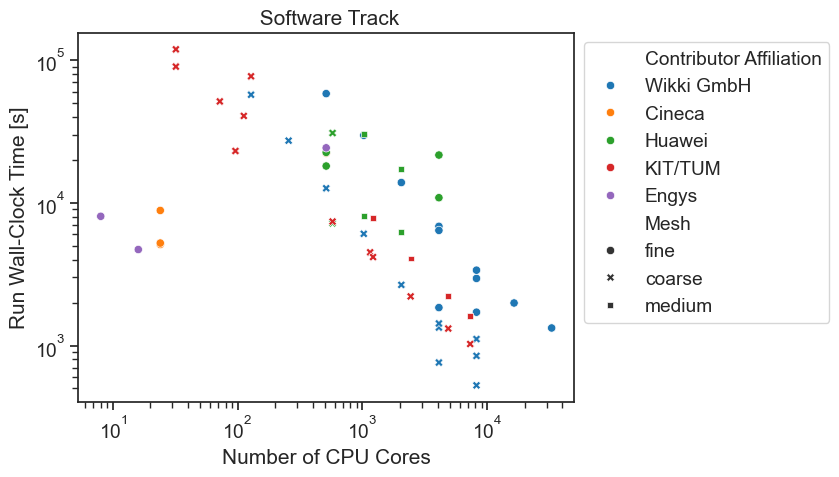

In [87]:
ax = sb.scatterplot(df_software,x="Number of CPU Cores", y="Run Wall-Clock Time [s]", hue="Contributor Affiliation", style="Mesh")
ax.set(xscale="log", yscale="log", title=" Software Track")
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "wct_cores_mesh", doSaveFig)

# FVOPS

In [88]:
from sklearn import datasets, linear_model
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from scipy.optimize import curve_fit
from scipy.stats import expon
import numpy as np

def fvops(nc, a, b):
    return  a * nc + b



In [91]:
gen = set(df_hw_coarse["CPU Generation"])

#for g in gen:
#    df_filt = df_hw_coarse[df_hw_coarse["CPU Generation"] == g]
#    
#    X = df_filt[["Number of CPU Cores"]]
#    y = df_filt[["Time-To-Solution [h]"]]

#regressor = LinearRegression()
#regressor.fit(X, y_fit)
#y_pred = regressor.predict(X)
#    try:
#        popt, pcov = curve_fit(tts, X.values.ravel(), y.values.ravel())
#        #popt, pcov = curve_fit(tts, X.values, y.values)
#        plt.plot(np.array([10,32000]), tts(np.array([10,32000]), *popt), color = 'blue')
#    except:
#        continue

ax.set(xscale="log", title="Coarse Mesh")
ax.set_yscale("log", base=2)

ax.yaxis.set_major_formatter(FormatStrFormatter('%.2g'))
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
addSecondaryAxisCellsPerCore(ax, size_coarse)
fig = ax.get_figure()

ax = sb.lineplot(
    df_software_fine,
    x="Number of Nodes",
    y="FVOPS",  
    hue="Software Optimization Category",
    marker="o"
)#, style="GPU Model")
ax.set(yscale="log", xscale="log", title=" Software Track")

ax = sb.scatterplot(
    df_software_fine,
    x="Number of Nodes",
    y="FVOPS",  
    hue="Software Optimization Category",
)#, style="GPU Model")

NameError: name 'df_hw_coarse' is not defined

In [92]:
df_wiki = df_hardware[df_hardware["Contributor Affiliation"] == "Wikki GmbH"]
df_wiki_lumi  = df_wiki[df_wiki["File Name"] == "01_Wikki_OHC1_DrivAer_Result_hardware_236M.xlsm"]
df_wiki_lumi = df_wiki_lumi[df_wiki_lumi["CPU Family"] == "AMD"] 

0 CoherentIO
1 MixedPrecission
2 Decomposer
3 FullGPUPort
4 Selective
saving figure to figures_swtrack/FVOPS_Nodes_GPUOptimizationType_Fine_fit.png


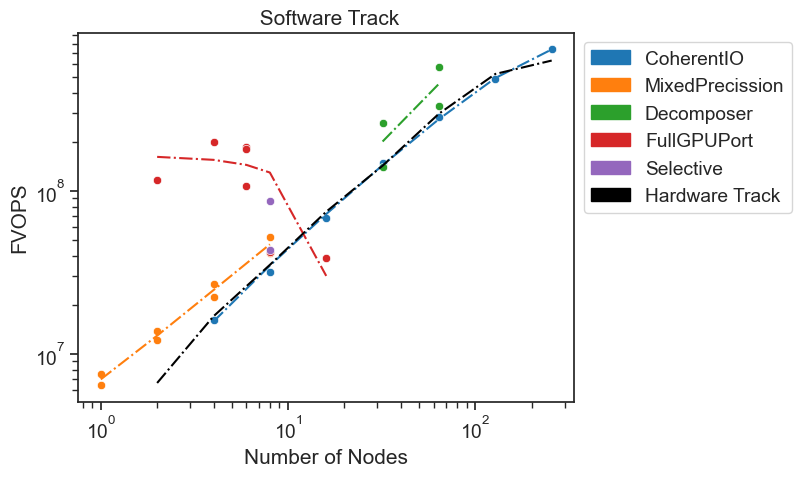

In [93]:
import matplotlib.patches as mpatches

df_software_fine = df_software[df_software["Mesh"] == "fine"]

gen = set(df_software_fine["Software Optimization Category"])
hf, ha = plt.subplots(1,1)
handles, labels = ha.get_legend_handles_labels()
patches = []

colors = sb.color_palette("tab10", 6) #  ["green", "blue", "red", "black", "cyan"]

for i,g in enumerate(gen):
    print(i, g)
    df_filt =  df_software_fine[ df_software_fine["Software Optimization Category"] == g]

    ax = sb.scatterplot(
        df_filt,
        x="Number of Nodes",
        y="FVOPS",  
        color=colors[i],
        ax = ha
    )

    # manually define a new patch 
    patches.append(mpatches.Patch(label=g, color=colors[i]))
    
    # handles is a list, so append manual patch
    # handles.append(patch) 

    if g == "Selective":
        continue
    X = df_filt[["Number of Nodes"]]
    y = df_filt[["FVOPS"]]
    
    poly_features = PolynomialFeatures(degree=2)
    X_ploy = poly_features.fit_transform(X) # convert the original feature to polynomial feature

    lin_reg = LinearRegression()
    lin_reg.fit(X_ploy,y)
    
    X_new = np.sort(X,axis = 0) # in order to plot the line of the model, we need to sort the the value of x-axis
    X_ploy = poly_features.fit_transform(X) # convert the original feature to polynomial feature

    X_new_ploy = poly_features.fit_transform(X_new) # compute the polynomial features 
    y_predict = lin_reg.predict(X_new_ploy) # make predictions using trained Linear Regression model

    
    #popt, pcov = curve_fit(fvops, X.values.ravel(), y.values.ravel())
    #plt.plot(np.array([1,512]), fvops(np.array([1,512]), *popt), color = colors[i], linestyle=":")
    plt.plot(X_new, y_predict, color = colors[i],linestyle="-.")


sb.lineplot(df_wiki_lumi, x="Number of Nodes", y="FVOPS", color="black", linewidth=1.5, linestyle="-.")
patches.append(mpatches.Patch(label="Hardware Track", color="black"))
handles.extend(patches)
plt.legend(handles=handles)

ax.set(yscale="log", xscale="log", title=" Software Track")
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "FVOPS_Nodes_GPUOptimizationType_Fine_fit", doSaveFig)

saving figure to figures_swtrack/FVOPS_Energy_OptimizationCat.png


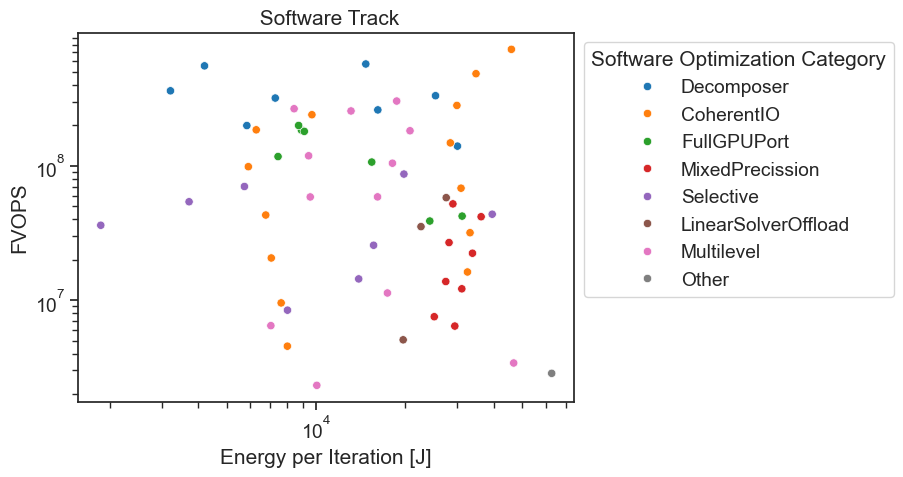

In [94]:
ax = sb.scatterplot(df_software,x="Energy per Iteration [J]", y="FVOPS", hue="Software Optimization Category")
ax.set(xscale="log", yscale="log", title=" Software Track")
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "FVOPS_Energy_OptimizationCat", doSaveFig)

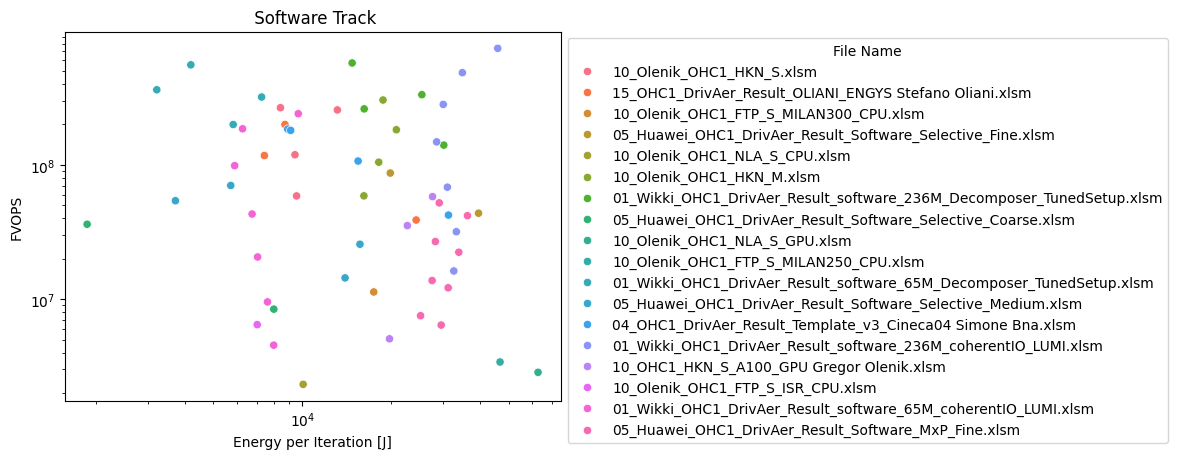

In [33]:
ax = sb.scatterplot(df_software,x="Energy per Iteration [J]", y="FVOPS", hue="File Name")
ax.set(xscale="log", yscale="log", title=" Software Track")
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "FVOPS_EnergyPerIteration_FileName", doSaveFig)

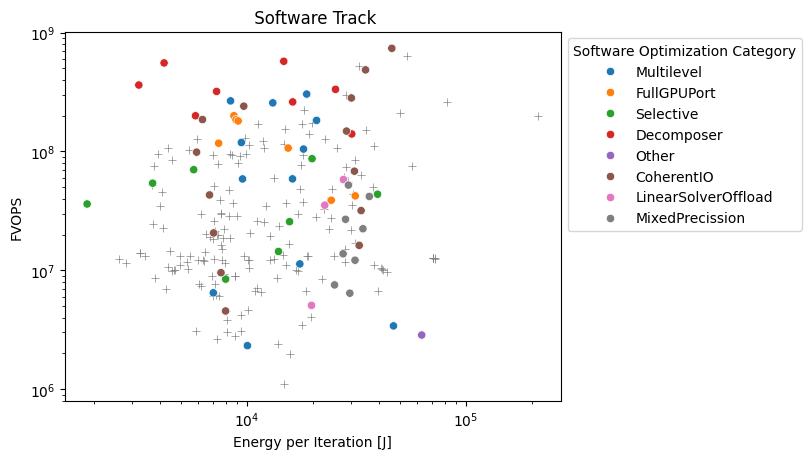

In [34]:
ax = sb.scatterplot(df_hardware,x="Energy per Iteration [J]", y="FVOPS", color="gray", marker="+")
ax = sb.scatterplot(df_software,x="Energy per Iteration [J]", y="FVOPS", hue="Software Optimization Category")
ax.set(xscale="log", yscale="log", title=" Software Track")
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "FVOPS_EnergyPerIteration_withHWTrack", doSaveFig)

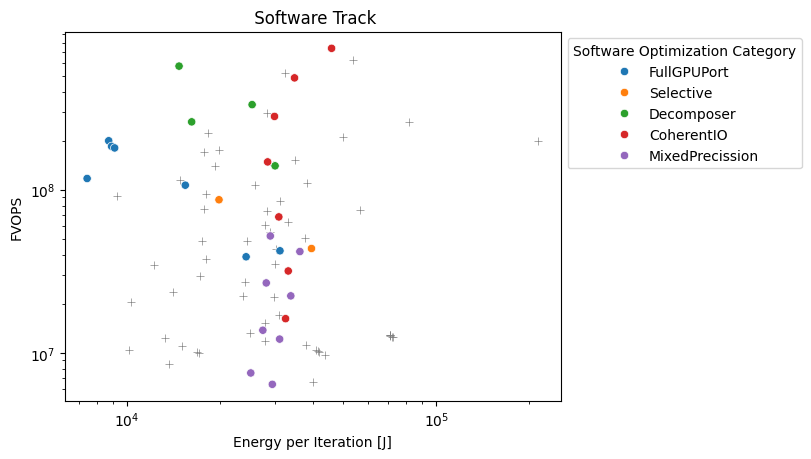

In [35]:
ax = sb.scatterplot(df_hardware_fine,x="Energy per Iteration [J]", y="FVOPS", color="gray", marker="+")
ax = sb.scatterplot(df_software_fine,x="Energy per Iteration [J]", y="FVOPS", hue="Software Optimization Category")
ax.set(xscale="log", yscale="log", title=" Software Track")
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "FVOPSEnergyPerIterationFine", doSaveFig)

# Scaling

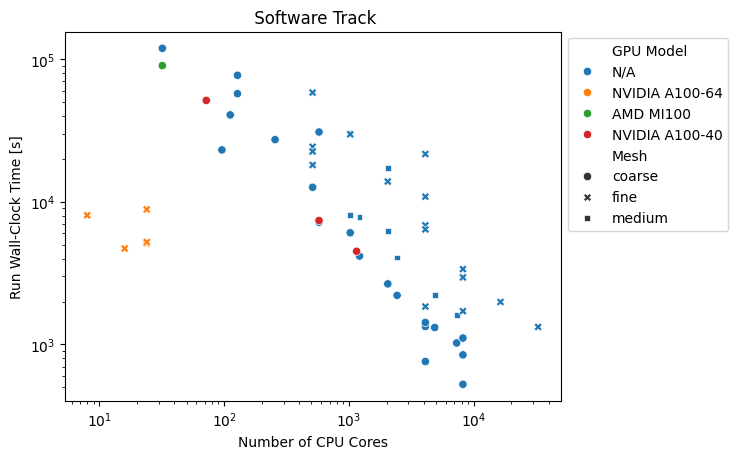

In [36]:
ax = sb.scatterplot(df_software,x="Number of CPU Cores", y="Run Wall-Clock Time [s]", hue="GPU Model", style="Mesh")
ax.set(xscale="log", yscale="log", title=" Software Track")
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "wct_cores_GPUModel", doSaveFig)

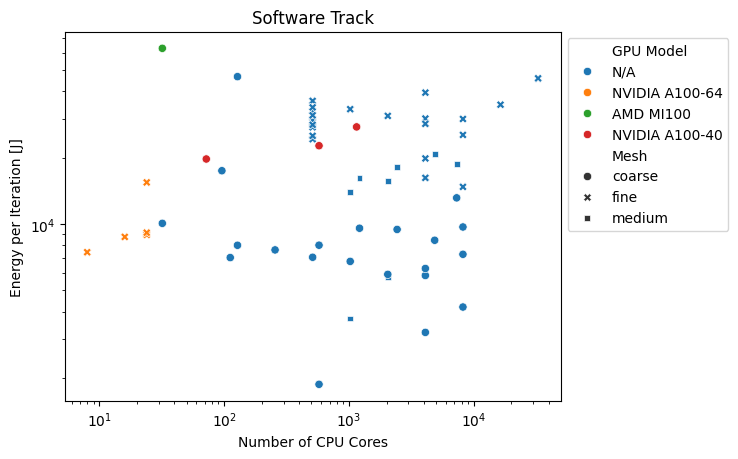

In [37]:
df_software_filt = df_software
ax = sb.scatterplot(df_software_filt,x="Number of CPU Cores", y="Energy per Iteration [J]", hue="GPU Model", style="Mesh")
ax.set(xscale="log", yscale="log", title="Software Track")
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "EnergyPerIteration_cores_GPUModel", doSaveFig)

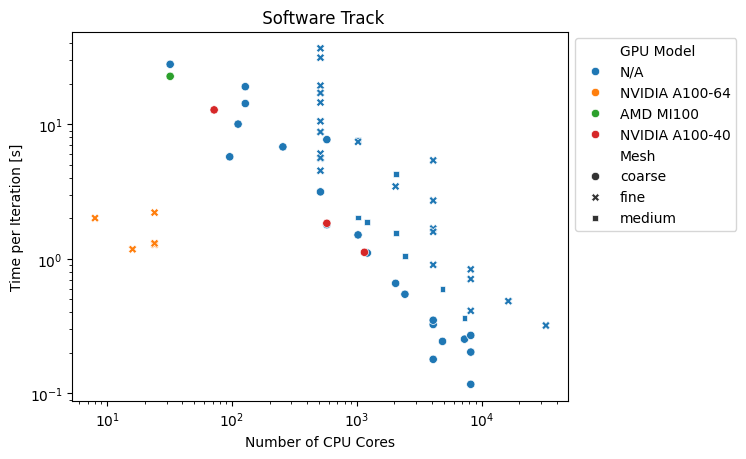

In [38]:
ax = sb.scatterplot(df_software,x="Number of CPU Cores", y="Time per Iteration [s]", hue="GPU Model", style="Mesh")
ax.set(xscale="log", yscale="log", title=" Software Track")
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "TimePerIteration_cores_GPUModel", doSaveFig)

# Aerodynamic Coefficients

/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_79372/2364517994.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_79372/2364517994.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_79372/2364517994.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(


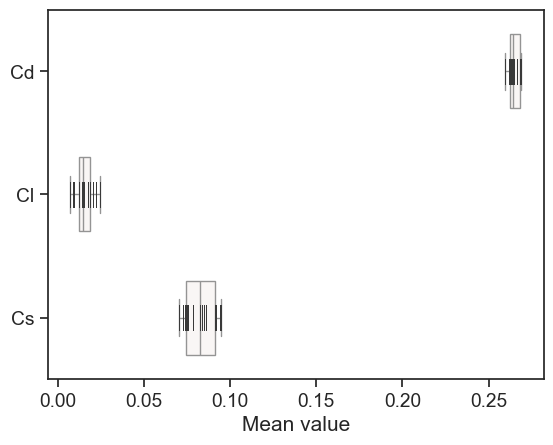

In [16]:
dsfs_clean = dfsf.dropna()
dsfs_clean = dsfs_clean[dsfs_clean["Contributor Affiliation"] != "CFD FEA SERVICE SRL"]
dsfs_clean["Cd mean"] = "Cd"
dsfs_clean["Cl mean"] = "Cl"
dsfs_clean["Cs mean"] = "Cs"

sb.boxplot(
    dsfs_clean, x="cd_mean", y="Cd mean",
    whis=[0, 100], width=.6, palette="vlag"
)
sb.boxplot(
    dsfs_clean, x="cl_mean", y="Cl mean",
    whis=[0, 100], width=.6, palette="vlag"
)
sb.boxplot(
    dsfs_clean, x="cs_mean", y="Cs mean",
    whis=[0, 100], width=.6, palette="vlag"
)
sb.stripplot(dsfs_clean, x="cd_mean", y="Cd mean", size=0.5, color=".3")
sb.stripplot(dsfs_clean, x="cl_mean", y="Cl mean", size=0.5, color=".3")
ax = sb.stripplot(dsfs_clean, x="cs_mean", y="Cs mean", size=0.5, color=".3")

ax.set(xlabel='Mean value', ylabel='')

fig = ax.get_figure()

In [61]:
dir()#.to_hex()

['__add__',
 '__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getnewargs__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__mul__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmul__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'count',
 'index']

/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_79372/2769352961.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["Cd"], size = 15)
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_79372/2769352961.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), size = 15)
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_79372/2769352961.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["Cl"], size = 15)
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_79372/2769352961.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get

saving figure to figures_swtrack/validation.png


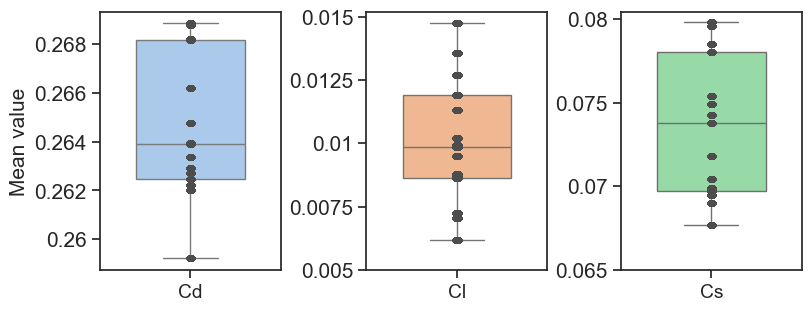

In [74]:
fig, axs = plt.subplots(1, 3, figsize=(6, 9), layout="constrained", 
                        #gridspec_kw={"hspace": 0.1},
                        sharey=False, sharex=False)
c = sb.color_palette("pastel")

sb.boxplot(
    dsfs_clean, y="cd_mean", x="Cd mean",
    whis=[0, 100], width=.6, 
    #palette="vlag",
    ax=axs[0],
    color=c[0],
)

ax = sb.stripplot(dsfs_clean, y="cd_mean", x="Cd mean", size=4, color=".3", ax=axs[0], jitter = 0.01)

ax.set_ylabel('Mean value', fontsize=15)
ax.set_xlabel('')
ax.set_yticklabels(["Cd"], size = 15)
ax.set_yticklabels(ax.get_yticks(), size = 15)

sb.boxplot(
    dsfs_clean, y="cl_mean", x="Cl mean",
    whis=[0, 100], width=.6, 
    #palette="vlag",
    ax=axs[1],
    #hue="Cl mean",
    color=c[1],
)
ax = sb.stripplot(dsfs_clean, y="cl_mean", x="Cl mean", size=4, color=".3", ax=axs[1], jitter = 0.01)

ax.set_ylabel('', fontsize=15)
ax.set_xlabel('')
ax.set_yticklabels(["Cl"], size = 15)
ax.set_yticklabels(ax.get_yticks(), size = 15)
ax.set_yticks(ax.get_yticks()[::2]);            # show every 2th tick


sb.boxplot(
    dsfs_clean, y="cs_mean", x="Cs mean",
    whis=[0, 100], width=.6,
    #palette="vlag",
    #hue="Cl mean",
    color=c[2],
    ax=axs[2]
)
ax = sb.stripplot(dsfs_clean, y="cs_mean", x="Cs mean", size=4, color=".3", ax=axs[2], jitter = 0.01)
#sb.stripplot(df_hardware, x="Nodes", y="Energy-To-Solution [kWh]", size=4, hue="CPU Generation")

ax.set_ylabel('', fontsize=15)
ax.set_xlabel('')
ax.set_yticklabels(["Cs"], size = 15)
ax.set_yticklabels(ax.get_yticks(), size = 15)
ax.set_yticks(ax.get_yticks()[::2]);            # show every 2th tick


fig = ax.get_figure()
fig.set_size_inches(8, 3)
op.save_fig(fig, fig_folder, "validation", doSaveFig)

/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_79372/292379111.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_79372/292379111.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["Cl"], size = 15)
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_79372/292379111.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), size = 15)


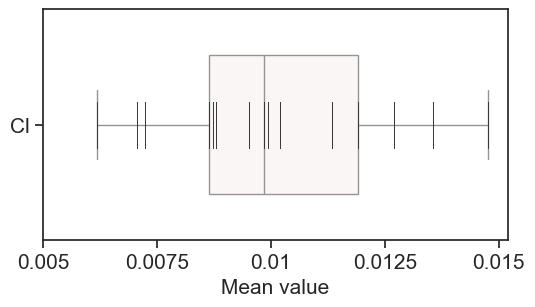

In [18]:
sb.boxplot(
    dsfs_clean, x="cl_mean", y="Cl mean",
    whis=[0, 100], width=.6, palette="vlag",
)
ax = sb.stripplot(dsfs_clean, x="cl_mean", y="Cl mean", size=0.5, color=".3")

ax.set_xlabel('Mean value', fontsize=15)
ax.set_ylabel('')
ax.set_yticklabels(["Cl"], size = 15)
ax.set_xticklabels(ax.get_xticks(), size = 15)
ax.set_xticks(ax.get_xticks()[::2]);            # show every 2th tick

fig = ax.get_figure()
fig.set_size_inches(6, 3)

/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_79372/2441014139.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_79372/2441014139.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["Cs"], size = 15)
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_79372/2441014139.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), size = 15)


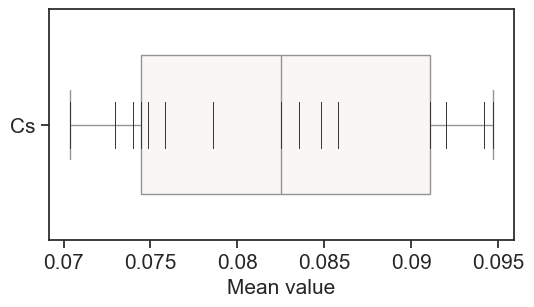

In [19]:
sb.boxplot(
    dsfs_clean, x="cs_mean", y="Cs mean",
    whis=[0, 100], width=.6, palette="vlag"
)
ax = sb.stripplot(dsfs_clean, x="cs_mean", y="Cs mean", size=0.5, color=".3")

ax.set_xlabel('Mean value', fontsize=15)
ax.set_ylabel('')
ax.set_yticklabels(["Cs"], size = 15)
ax.set_xticklabels(ax.get_xticks(), size = 15)

fig = ax.get_figure()
fig.set_size_inches(6, 3)